            BANK ATM SYSTEM SIMULATION REPORT
Total Active ATM Machines   : 2
Total Simulated Customers  : 30
Average Customer Arrival    : Every 2.0 min
Average Cash Withdrawal Time: 3.5 min
-------------------------------------------------------
RESULT -> MAXIMUM QUEUE LENGTH: 5 customers


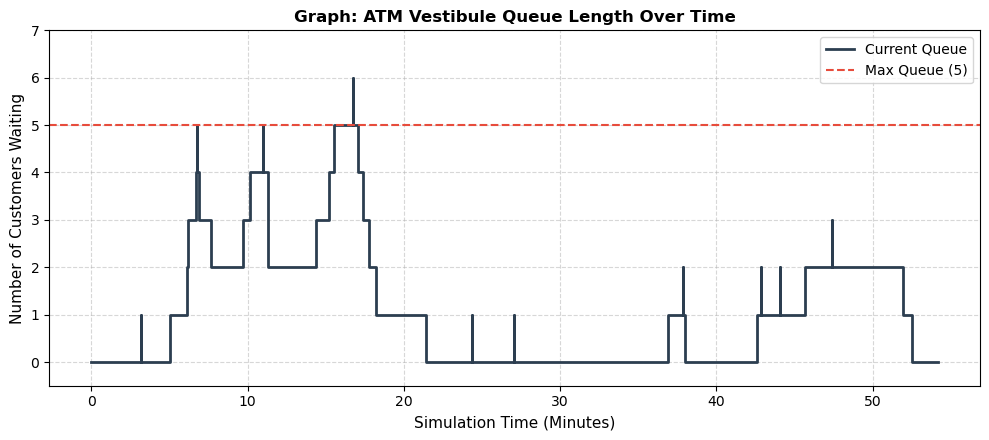

In [5]:
import random
import simpy
import matplotlib.pyplot as plt

# --- ১. প্যারামিটার সেটআপ ---
RANDOM_SEED = 42
NUM_ATMS = 2          # বুথে এটিএম মেশিনের সংখ্যা (Servers)
ARRIVAL_RATE = 2.0    # গড়ে প্রতি ২ মিনিটে ১ জন কাস্টমার আসবে
SERVICE_TIME = 3.5    # টাকা তুলতে গড়ে ৩.৫ মিনিট লাগবে
TOTAL_CUSTOMERS = 30  # মোট ৩০ জন কাস্টমার নিয়ে টেস্ট করব

# গ্রাফের জন্য ডাটা ট্র্যাকিং
time_log = [0]
queue_log = [0]
max_queue_length = 0

def atm_customer(env, name, bank_booth):
    global max_queue_length
    
    # কাস্টমার বুথে আসলো
    current_q = len(bank_booth.queue)
    time_log.append(env.now)
    queue_log.append(current_q)
    
    with bank_booth.request() as request:
        yield request
        
        # কাস্টমার মেশিনে টাকা তোলা শুরু করল (লাইন থেকে কমে গেল)
        current_q = len(bank_booth.queue)
        time_log.append(env.now)
        queue_log.append(current_q)
        
        # ম্যাক্সিমাম কিউ লেন্থ আপডেট করা
        if current_q > max_queue_length:
            max_queue_length = current_q
            
        # টাকা তোলার সময় পার হওয়া
        duration = random.expovariate(1.0 / SERVICE_TIME)
        yield env.timeout(duration)
        
        # কাস্টমার বুথ ছেড়ে চলে গেল
        current_q = len(bank_booth.queue)
        time_log.append(env.now)
        queue_log.append(current_q)

def customer_generator(env, bank_booth):
    for i in range(TOTAL_CUSTOMERS):
        yield env.timeout(random.expovariate(1.0 / ARRIVAL_RATE))
        env.process(atm_customer(env, f"Cust {i+1}", bank_booth))

# --- ২. সিমুলেশন রান করা ---
random.seed(RANDOM_SEED)
env = simpy.Environment()
bank_booth = simpy.Resource(env, capacity=NUM_ATMS) # ২ টি এটিএম রিসোর্স

env.process(customer_generator(env, bank_booth))
env.run()

# --- ৩. টেক্সট রিপোর্ট প্রিন্ট ---
print("=" * 55)
print("            BANK ATM SYSTEM SIMULATION REPORT")
print("=" * 55)
print(f"Total Active ATM Machines   : {NUM_ATMS}")
print(f"Total Simulated Customers  : {TOTAL_CUSTOMERS}")
print(f"Average Customer Arrival    : Every {ARRIVAL_RATE} min")
print(f"Average Cash Withdrawal Time: {SERVICE_TIME} min")
print("-" * 55)
print(f"RESULT -> MAXIMUM QUEUE LENGTH: {max_queue_length} customers")
print("=" * 55)

# --- ৪. গ্রাফ প্রদর্শন (ATM Queue Graph) ---
plt.figure(figsize=(10, 4.5))
plt.step(time_log, queue_log, where='post', color='#2c3e50', linewidth=2, label='Current Queue')
plt.axhline(max_queue_length, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Max Queue ({max_queue_length})')

plt.title("Graph: ATM Vestibule Queue Length Over Time", fontsize=12, fontweight='bold')
plt.xlabel("Simulation Time (Minutes)", fontsize=11)
plt.ylabel("Number of Customers Waiting", fontsize=11)
plt.ylim(-0.5, max_queue_length + 2)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()